# Working of LangChain Agents

A LangChain Agent combines a **Large Language Model (LLM)** with one or more **Tools** (such as web search, databases, calculators, APIs, or custom functions). The agent decides whether it can answer a user's query using its own knowledge or whether it needs to use a tool.

## Workflow

1. The user submits a query to the agent.

2. The agent first sends the query to the **LLM** for reasoning.

3. The LLM decides whether it can answer the question directly.
   - **If YES:** The agent returns the answer immediately.
   - **If NO:** The agent selects the most appropriate tool.

4. The selected tool is executed (for example, a web search, calculator, database query, or API call).

5. The tool's output is returned to the LLM.

6. The LLM analyzes the tool's result.
   - If sufficient information is available, it generates the final answer.
   - If more information is required, it may call another tool.

7. This reasoning → tool execution → reasoning process continues until the agent has enough information to answer the user's query.

8. Finally, the agent returns the complete response to the user.

---

## Workflow Diagram

```text
             User Query
                  │
                  ▼
            LangChain Agent
                  │
                  ▼
                LLM
           (Reasoning Step)
          ┌────────┴────────┐
          │                 │
     Can Answer?         Needs Tool?
          │                 │
        Yes                Yes
          │                 │
          ▼                 ▼
   Return Answer      Select Tool
                            │
                            ▼
                    Execute Tool
                            │
                            ▼
                     Tool Result
                            │
                            ▼
                         LLM Again
                            │
                  Enough Information?
                   ┌────────┴────────┐
                   │                 │
                 Yes                No
                   │                 │
                   ▼                 ▼
          Return Final Answer   Call Another Tool
```

## Key Points

- The **LLM acts as the brain** of the agent.
- **Tools** provide external knowledge or perform actions that the LLM cannot do on its own.
- The agent decides **which tool to use and when to use it**.
- The reasoning and tool-calling process continues until the LLM has enough information to generate the final answer.

### What are Tools in LangChain?

Tools are external functions or services that a LangChain Agent uses to perform tasks that an LLM cannot do by itself. They help the agent access real-time information, perform calculations, search databases, call APIs, or execute custom functions.

In [ ]:
pip install langchain_community

In [ ]:
!pip install -U langchain langchain-community ddgs

In [4]:
from langchain_community.tools import ddg_search, DuckDuckGoSearchRun


/tmp/ipykernel_4909/869477865.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import ddg_search, DuckDuckGoSearchRun


In [5]:
search=DuckDuckGoSearchRun()

In [6]:
search.invoke('Latest country visit by Prime Minister of India')

'First visit by an Indian Prime Minister to Cyprus since 2002. Prime Minister Modi was awarded the Grand Cross of the Order of Makarios III by the President of Cyprus Nikos Christodoulides. Prime Minister of India. Indian Parliament. Press Information Bureau.We must connect every class, every country, every society, and every region of the world. And this is the essence of the One Family concept. During the visit, Prime Minister will hold talks with President Herminie to review the full spectrum of bilateral cooperation and exchange views on regional and international issues of mutual interest. Prime Minister Narendra Modi arrived in Argentina on Friday evening (local time) for a two-day visit which also marks the first prime ministerial-level bilateral visit from India to Argentina in 57 years. PM Modi had previously visited the country in 2018 to attend the G20 Summit.LATEST. During the visit, Prime Minister Modi was accorded an official welcoming ceremony at the Perdana Putra Comple

In [8]:
search.invoke('Gudivada located in')

'May 24, 2026 - The presence of Habitation at this ... per some inscriptions. Archaeological excavations conducted at Gudivada yielded an ancient Buddhist stupa mound and Jain relics. Gudivada is religiously diversified city with many Hindu Temples and important Jain Tirth of Bhagawan Parshvanath located at market ... November 23, 2025 - Gudivada or Peddapuram is a village in Peddapuram Mandal, East Godavari district of Andhra Pradesh. January 2, 2026 - Gudivada mandal is one of the 25 mandals in Krishna district of the state of Andhra Pradesh in India. It is under the administration of Gudivada revenue division and the headquarters are located at Gudivada town. November 23, 2025 - Gudivada (rural) is a village in Krishna district of the Indian state of Andhra Pradesh. It is located in Gudivada mandal of Nuzvid revenue division. April 24, 2026 - Gudivada Assembly constituency is a constituency in Krishna district of Andhra Pradesh that elects representatives to the Andhra Pradesh Legis

Search using `LELC ` chain

In [5]:
pip install -qU langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.5/70.5 kB 3.5 MB/s eta 0:00:00


In [19]:
from google.colab import userdata
import os
from langchain_groq import ChatGroq
os.environ['GROQ_API_KEY']=userdata.get('Gork_Key')
llm = ChatGroq(
    model="qwen/qwen3-32b"
)

# !!!! Never Use `GEMINI ` for Agents

In [14]:
from langchain_core.output_parsers import StrOutputParser
parser=StrOutputParser()

In [15]:
from langchain_core.prompts import SystemMessagePromptTemplate, HumanMessagePromptTemplate, ChatPromptTemplate

In [22]:
system_msg= "Hey LLM, You are Expect in dealing things, but some reason just forgot everthing and search from given search enging, get results from there , Give the aswer in single sentence"
human_msg=HumanMessagePromptTemplate.from_template(' what is the latest country, Prime Minister {PMO} visited recently')

In [23]:
Prompt_var=ChatPromptTemplate.from_messages([system_msg,human_msg])

In [19]:
# tools
from langchain_community.tools import ddg_search, DuckDuckGoSearchRun
Duck_Search=DuckDuckGoSearchRun()



In [27]:
chain= Prompt_var|llm|parser|Duck_Search

In [28]:
chain

ChatPromptTemplate(input_variables=['PMO'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='Hey LLM, You are Expect in dealing things, but some reason just forgot everthing and search from given search enging, get results from there , Give the aswer in single sentence'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['PMO'], input_types={}, partial_variables={}, template=' what is the latest country, Prime Minister {PMO} visited recently'), additional_kwargs={})])
| ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.4.7', 'langchain': '1.3.11', 'langchain-google-genai': '4.2.6'}}, profile={'name': 'Gemini 2.5 Flash', 'release_date': '2025-03-20', 'last_updated': '2025-06-05', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs'

In [29]:
chain.invoke({
    'PMO': 'INDIA'
})

'Jun 14, 2024 · PM Modi thanked PM Meloni for the invitation to participate in G7 Outreach Summit and conveyed his appreciation for the successful conclusion of the Summit. The two leaders noted with satisfaction the regular higher political dialogue and reviewed progress of the India-Italy Strategic Partnership. Jul 26, 2024 · Prime Minister Modi’s visit to Italy for the G7 summit reaffirmed India’s diplomatic strength and bolstered bilateral ties with Italy. The camaraderie between Modi and Meloni underscored a deepening strategic partnership marked by mutual respect and shared goals for global peace and prosperity. Jun 15, 2024 · Prime Minister Narendra Modi returned to New Delhi on Saturday after attending the G7 Summit in Italy, marking his first international trip in his third term in office. Prime Minister Narendra Modi visited Italy from June 13-15, 2024, to attend the G7 Summit at the invitation of PM Giorgia Meloni. During the Summit, the PM held interactions with several wor

In [30]:
chain.invoke({
    'PMO': 'Russia'
})

"Mikhail Vladimirovich Mishustin is a Russian politician and economist serving as the prime minister of Russia since 2020. He previously served as the director of the Federal Taxation Service from 2010 to 2020. Russian Prime Minister Mikhail Mishustin visited China on May 23-24. He started his journey in Shanghai, where he attended China-Russia business forum.The visit is expected to yield a plan of contacts between the two countries’ foreign ministries in the coming years. Russian Prime Minister Mikhail Mishustin (file photo). Pressure from the West is strengthening Russia's ties with China, Russian Prime Minister Mikhail Mishustin said in a meeting with his Chinese counterpart in Beijing on May 24. Russian Prime Minister Mikhail Mishustin is expected to visit China from May 23 to 24, Beijing’s foreign ministry and Kremlin confirmed on Friday. Franked by senior officials including his two deputies and several ministers, the Prime Minister of Russia Mikhail Mishustin visited the People

### AGENTS

In [ ]:
!pip install -U langchain langchain-community ddgs

In [12]:
from langchain.agents import create_agent
from langchain_community.tools import ddg_search, DuckDuckGoSearchRun
SearchObj=DuckDuckGoSearchRun()
from langchain.tools import tool

In [50]:
pip install -qU langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 5.2 MB/s eta 0:00:00


In [52]:
from google.colab import userdata
import os
from langchain_groq import ChatGroq
os.environ['GROQ_API_KEY']=userdata.get('Gork_Key')
llm = ChatGroq(
    model="qwen/qwen3-32b"
)

In [63]:
@tool # decorater converts a normal Python function into a LangChain Tool that an LLM or Agent can understand and use.
def search_func(query):
  '''
  Lets Search the user Query carefully, by using tool and User Prompt , makesure
  Give the output result Clean
  for LMM :Hey LLM, You are Expect in dealing things, but some reason just forgot everthing and search from given search enging, get results from there , Give the aswer in single sentence"
  '''
  return SearchObj.invoke(query)

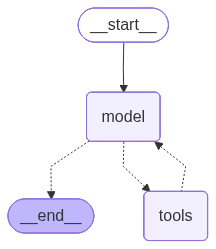

In [72]:
agent=create_agent(
    model=llm,
    tools=[search_func]
)
agent

In [73]:
Prompt_var=ChatPromptTemplate.from_messages([
    HumanMessagePromptTemplate.from_template(' what is the latest country, Prime Minister Modi visited recently')
])

In [74]:
Chain= Prompt_var|agent
Chain

ChatPromptTemplate(input_variables=[], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template=' what is the latest country, Prime Minister Modi visited recently'), additional_kwargs={})])
| <langgraph.graph.state.CompiledStateGraph object at 0x7acd9fbc7980>

In [75]:
Chain.invoke({})

{'messages': [HumanMessage(content=' what is the latest country, Prime Minister Modi visited recently', additional_kwargs={}, response_metadata={}, id='15a41b98-0f96-4a9b-a480-3f8cc8c9a75f'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking which is the latest country that Prime Minister Modi visited recently. I need to figure out how to approach this. Since my knowledge might not be up-to-date, the best way is to use the search function provided. Let me check the available tools. There\'s a function called search_func that takes a query parameter. I should call this function with the user\'s query to get the latest information. The user wants the most recent visit, so the search should focus on recent news. I\'ll structure the tool call with the query "latest country visited by Prime Minister Modi" to get accurate results. Once I get the search results, I can extract the country name and present it in a single sentence as per the instructions.\